<a href="https://colab.research.google.com/github/VattamYasritha/Deep_Learning/blob/main/DL%20EXP2/exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf

# XOR Dataset
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=np.float32)

Y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)

# Function to build model
def create_model(loss_function):

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(5,
                              activation='sigmoid',
                              input_shape=(2,)),
        tf.keras.layers.Dense(1,
                              activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss=loss_function,
        metrics=['accuracy']
    )

    return model

# Model A (MSE)
model_mse = create_model('mse')

history_mse = model_mse.fit(
    X,
    Y,
    epochs=3000,
    verbose=0
)

# Model B (BCE)
model_bce = create_model('binary_crossentropy')

history_bce = model_bce.fit(
    X,
    Y,
    epochs=3000,
    verbose=0
)

loss_mse, acc_mse = model_mse.evaluate(X,Y,verbose=0)
loss_bce, acc_bce = model_bce.evaluate(X,Y,verbose=0)

print("="*45)
print(" LOSS FUNCTION COMPARISON ")
print("="*45)

print("\nModel A (MSE)")
print("Loss :", round(loss_mse,4))
print("Accuracy : {:.2f}%".format(acc_mse*100))

print("\nModel B (BCE)")
print("Loss :", round(loss_bce,4))
print("Accuracy : {:.2f}%".format(acc_bce*100))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 LOSS FUNCTION COMPARISON 

Model A (MSE)
Loss : 0.1557
Accuracy : 75.00%

Model B (BCE)
Loss : 0.1028
Accuracy : 100.00%


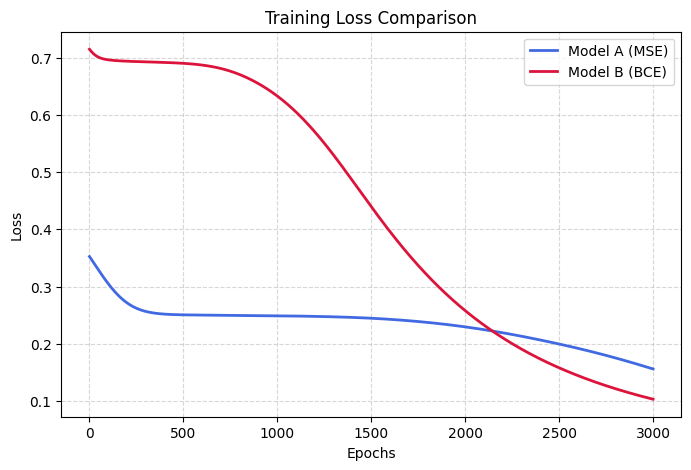


Comparison Summary
--------------------------------------------
Model	Loss	Accuracy
--------------------------------------------
MSE	0.1557	75.00%
BCE	0.1028	100.00%
--------------------------------------------


In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_mse.history['loss'],
         label='Model A (MSE)',
         linewidth=2,
         color='royalblue')

plt.plot(history_bce.history['loss'],
         label='Model B (BCE)',
         linewidth=2,
         color='crimson')

plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.show()

print("\nComparison Summary")

print("--------------------------------------------")
print("Model\tLoss\tAccuracy")
print("--------------------------------------------")
print("MSE\t{:.4f}\t{:.2f}%".format(loss_mse,acc_mse*100))
print("BCE\t{:.4f}\t{:.2f}%".format(loss_bce,acc_bce*100))
print("--------------------------------------------")